<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [ ]:
#imports important packages
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
#imports api from provider
from serpapi import EbaySearch

#parameters for api search
params = {
    "engine": "ebay",
    "_nkw": "jack hughes young guns psa 10",
    "ebay_domain": "ebay.com",
    "api_key": "12a13973b8d58a4cc7b569859b257ef029573e1b3f116a9ecfcebd95b1f016a5",
    "show_only": "Sold",
    "buying_format": "BIN",
    "lh_sold": "1",
    "_ipg": "200"
}

#displays results
search = EbaySearch(params)
results = search.get_dict()
for result in results["organic_results"]:
    # Check if 'price' exists and has a 'raw' key before trying to access it
    if 'price' in result and isinstance(result['price'], dict) and 'raw' in result['price']:
        print(f"Title: {result['title']}, Price: {result['price']['raw']}")
    # If 'price' exists but doesn't have 'raw', try to print the price directly
    elif 'price' in result:
        print(f"Title: {result['title']}, Price: {result['price']}")
    # If no price information is available
    else:
        print(f"Title: {result['title']}, Price: Not available")
    print(result.get("sold_date"))
data_json = json.dumps(results)


    #parameters for api search
params = {
    "engine": "ebay",
    "_nkw": "jack hughes young guns",
    "ebay_domain": "ebay.com",
    "api_key": "12a13973b8d58a4cc7b569859b257ef029573e1b3f116a9ecfcebd95b1f016a5",
    "show_only": "Sold",
    "buying_format": "BIN",
    "lh_sold": "1",
    "_ipg": "200"
}

#displays results
search2 = EbaySearch(params)
results2 = search.get_dict()
for result in results["organic_results"]:
    # Check if 'price' exists and has a 'raw' key before trying to access it
    if 'price' in result and isinstance(result['price'], dict) and 'raw' in result['price']:
        print(f"Title: {result['title']}, Price: {result['price']['raw']}")
    # If 'price' exists but doesn't have 'raw', try to print the price directly
    elif 'price' in result:
        print(f"Title: {result['title']}, Price: {result['price']}")
    # If no price information is available
    else:
        print(f"Title: {result['title']}, Price: Not available")
    print(result.get("sold_date"))

data_json2 = json.dumps(results2)

df1 = pd.DataFrame(results["organic_results"])
df1.to_csv("output1.csv", index=False)

df2 = pd.DataFrame(results2["organic_results"])
df2.to_csv("output2.csv", index=False)

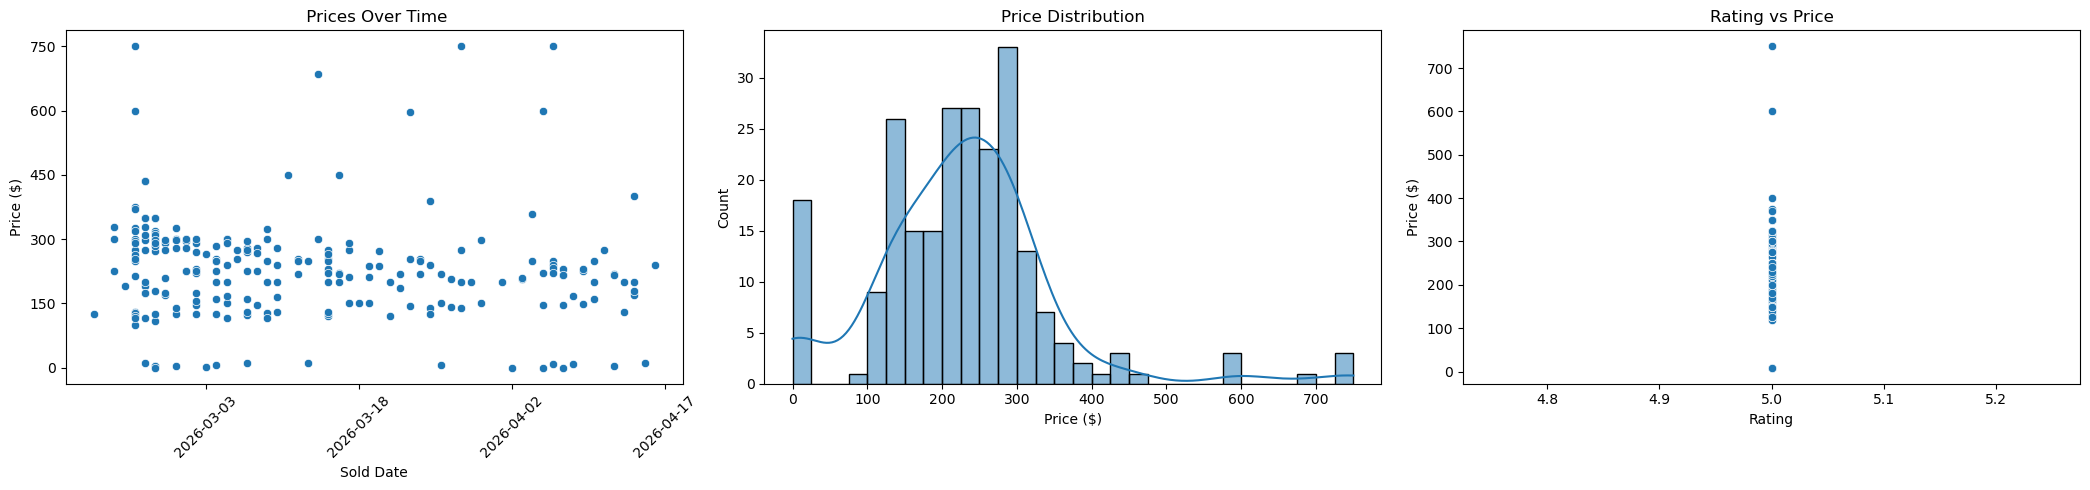

In [164]:
pythonfig, axs = plt.subplots(ncols=3, figsize=(21, 5))

# Left: price over time
sns.scatterplot(data=df1, x='sold_date', y='price', ax=axs[0])
axs[0].yaxis.set_major_locator(plt.MaxNLocator(6))
axs[0].xaxis.set_major_locator(plt.MaxNLocator(6))
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_title(" Prices Over Time")
axs[0].set_xlabel("Sold Date")
axs[0].set_ylabel("Price ($)")

# Middle: price distribution
sns.histplot(data=df2, x='price', bins=30, kde=True, ax=axs[1])
axs[1].set_title( "Price Distribution")
axs[1].set_xlabel("Price ($)")
axs[1].set_ylabel("Count")

# Right: rating vs price
sns.scatterplot(data=df1, x='rating', y='price', ax=axs[2])
axs[2].set_title("Rating vs Price")
axs[2].set_xlabel("Rating")
axs[2].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

1= The first graph demonstrates prices over time for hockey cards. It is seen that there is a range which they are commonly sold at.
2= Second graph demonstrates price distribution. We can see that it is a right-skewed distribution
3= Third graph demonstrates rating vs price. It seems that all the sellers are at 5 star ratings.